In [8]:
import numpy as np

# Question 10
prices = np.array([
    [100, 108, 103, 115, 110, 119, 125, 121, 130, 127, 135, 140],  # Stock A
    [200, 195, 210, 205, 220, 215, 225, 230, 222, 235, 240, 238]   # Stock B
])

# (a)
returns_10 = (prices[:, 1:] - prices[:, :-1]) / prices[:, :-1]
print("(a) Monthly Returns (Shape: {}) ".format(returns_10.shape))
print(returns_10, "\n")

# (b)
mean_monthly = np.mean(returns_10, axis=1)
std_monthly = np.std(returns_10, axis=1, ddof=1)
ann_mean = mean_monthly * 12
ann_std = std_monthly * np.sqrt(12)
print(" (b) Annualised Statistics ")
print(f"Stock A - Mean: {ann_mean[0]:.4f}, Std Dev: {ann_std[0]:.4f}")
print(f"Stock B - Mean: {ann_mean[1]:.4f}, Std Dev: {ann_std[1]:.4f}\n")

# (c)
cov_matrix = np.cov(returns_10)
print(" (c) Covariance Matrix ")
print(cov_matrix)

(a) Monthly Returns (Shape: (2, 11)) 
[[ 0.08       -0.0462963   0.11650485 -0.04347826  0.08181818  0.05042017
  -0.032       0.07438017 -0.02307692  0.06299213  0.03703704]
 [-0.025       0.07692308 -0.02380952  0.07317073 -0.02272727  0.04651163
   0.02222222 -0.03478261  0.05855856  0.0212766  -0.00833333]] 

 (b) Annualised Statistics 
Stock A - Mean: 0.3909, Std Dev: 0.2020
Stock B - Mean: 0.2007, Std Dev: 0.1458

 (c) Covariance Matrix 
[[ 0.00340013 -0.00206426]
 [-0.00206426  0.00177196]]


In [9]:
# Question 11
mu_11 = np.array([0.15, 0.08, 0.05])
Sigma_11 = np.array([
    [0.0625, 0.0120, 0.0010],
    [0.0120, 0.0144, 0.00096],
    [0.0010, 0.00096, 0.0016]
])

# (a)
w_eq = np.array([1/3, 1/3, 1/3])
E_Rp_eq = w_eq @ mu_11
var_Rp_eq = w_eq.T @ Sigma_11 @ w_eq
print(" (a) Equal Weight Portfolio ")
print(f"Expected Return: {E_Rp_eq:.4f}")
print(f"Variance: {var_Rp_eq:.6f}\n")

# (b)
np.random.seed(42)
weights = np.random.dirichlet(np.ones(3), size=10000)
port_returns = weights @ mu_11
port_vars = np.sum(weights * (weights @ Sigma_11), axis=1)
port_stds = np.sqrt(port_vars)
print(" (b) Simulated Portfolios ")
print(f"Generated {len(weights)} portfolios. First 3 Returns: {port_returns[:3]}\n")

# (c)
sharpe_ratios = port_returns / port_stds
max_sr_idx = np.argmax(sharpe_ratios)
max_sr = sharpe_ratios[max_sr_idx]
optimal_weights = weights[max_sr_idx]
print("(c) Maximum Sharpe Ratio ")
print(f"Max Sharpe Ratio: {max_sr:.4f}")
print(f"Optimal Weights: {optimal_weights}")

 (a) Equal Weight Portfolio 
Expected Return: 0.0933
Variance: 0.011824

 (b) Simulated Portfolios 
Generated 10000 portfolios. First 3 Returns: [0.07861272 0.12697316 0.07217974]

(c) Maximum Sharpe Ratio 
Max Sharpe Ratio: 1.3628
Optimal Weights: [0.04660024 0.06652069 0.88687907]


In [11]:
# Question 12
mu1, sig1 = 0.12, 0.20
mu2, sig2 = 0.06, 0.10
w1 = 0.6
w2 = 1 - w1

# (a)
rho_array = np.linspace(-1, 1, 200)
var_p_array = (w1**2 * sig1**2) + (w2**2 * sig2**2) + (2 * w1 * w2 * rho_array * sig1 * sig2)
std_p_array = np.sqrt(var_p_array)
print(" (a) Array Shapes ")
print(f"rho_array shape: {rho_array.shape}, std_p_array shape: {std_p_array.shape}\n")

# (b)
min_idx = np.argmin(std_p_array)
min_rho = rho_array[min_idx]
min_std = std_p_array[min_idx]
print("(b) Minimum Risk ")
print(f"Minimum standard deviation is {min_std:.4f} at a correlation of {min_rho:.2f}")

 (a) Array Shapes 
rho_array shape: (200,), std_p_array shape: (200,)

(b) Minimum Risk 
Minimum standard deviation is 0.0800 at a correlation of -1.00


In [12]:
# Question 13 and 14

import pandas as pd

np.random.seed(0)
dates = pd.date_range('2023-01-02', periods=52, freq='W-MON')
mu_weekly = np.array([0.003, 0.002, 0.001, 0.0015])
sig_weekly = np.array([0.04, 0.03, 0.02, 0.025])
returns_sim = np.random.normal(mu_weekly, sig_weekly, (52, 4))
prices_sim = 100 * np.cumprod(1 + returns_sim, axis=0)
df = pd.DataFrame(prices_sim, index=dates, columns=['AAPL', 'MSFT', 'GOOGL', 'AMZN'])

print("QUESTION 13")
# 13(a)
df_returns = df.pct_change().dropna()
print("\n (a) First 3 rows of weekly returns ")
print(df_returns.head(3))
print(f"DataFrame Shape: {df_returns.shape}")

# 13(b)
desc = df_returns.describe()
highest_mean = desc.loc['mean'].idxmax()
highest_std = desc.loc['std'].idxmax()
print("\n (b) Summary Statistics ")
print(f"Asset with highest mean return: {highest_mean}")
print(f"Asset with highest standard deviation: {highest_std}")

# 13(c)
rf_annual = 0.02
ann_sr = (df_returns.mean() * 52 - rf_annual) / (df_returns.std() * np.sqrt(52))
print("\n--- (c) Annualised Sharpe Ratios ---")
print(ann_sr)

print("\n QUESTION 14 ")
# 14(a)
corr_matrix = df_returns.corr()
lowest_corr_pair = corr_matrix.replace(1, np.nan).stack().idxmin()
print("\n (a) Correlation Matrix ")
print(corr_matrix)
print(f"\nPair with lowest correlation: {lowest_corr_pair}")

# 14(b)
w_eq_pd = pd.Series([0.25, 0.25, 0.25, 0.25], index=df_returns.columns)
port_series_weekly = df_returns.dot(w_eq_pd)
print("\n (b) Equal-Weight Weekly Portfolio Returns (First 3) ")
print(port_series_weekly.head(3))

# 14(c)
port_series_monthly = port_series_weekly.resample('ME').apply(lambda x: np.prod(1 + x) - 1)
print("\n (c) Monthly Resampled Portfolio ")
print(f"Monthly Mean: {port_series_monthly.mean():.4f}")
print(f"Monthly Std Dev: {port_series_monthly.std():.4f}")

QUESTION 13

 (a) First 3 rows of weekly returns 
                AAPL      MSFT     GOOGL      AMZN
2023-01-09  0.077702 -0.027318  0.020002 -0.002284
2023-01-16 -0.001129  0.014318  0.003881  0.037857
2023-01-23  0.033442  0.005650  0.009877  0.009842
DataFrame Shape: (51, 4)

 (b) Summary Statistics 
Asset with highest mean return: AMZN
Asset with highest standard deviation: AAPL

--- (c) Annualised Sharpe Ratios ---
AAPL     0.824485
MSFT     0.397113
GOOGL   -0.537553
AMZN     1.794045
dtype: float64

 QUESTION 14 

 (a) Correlation Matrix 
           AAPL      MSFT     GOOGL      AMZN
AAPL   1.000000 -0.075324  0.190733  0.060147
MSFT  -0.075324  1.000000  0.287278  0.069544
GOOGL  0.190733  0.287278  1.000000 -0.001252
AMZN   0.060147  0.069544 -0.001252  1.000000

Pair with lowest correlation: ('AAPL', 'MSFT')

 (b) Equal-Weight Weekly Portfolio Returns (First 3) 
2023-01-09    0.017025
2023-01-16    0.013732
2023-01-23    0.014703
Freq: W-MON, dtype: float64

 (c) Monthly Resa

Plot saved as 'week1_plots.png'. Displaying below:


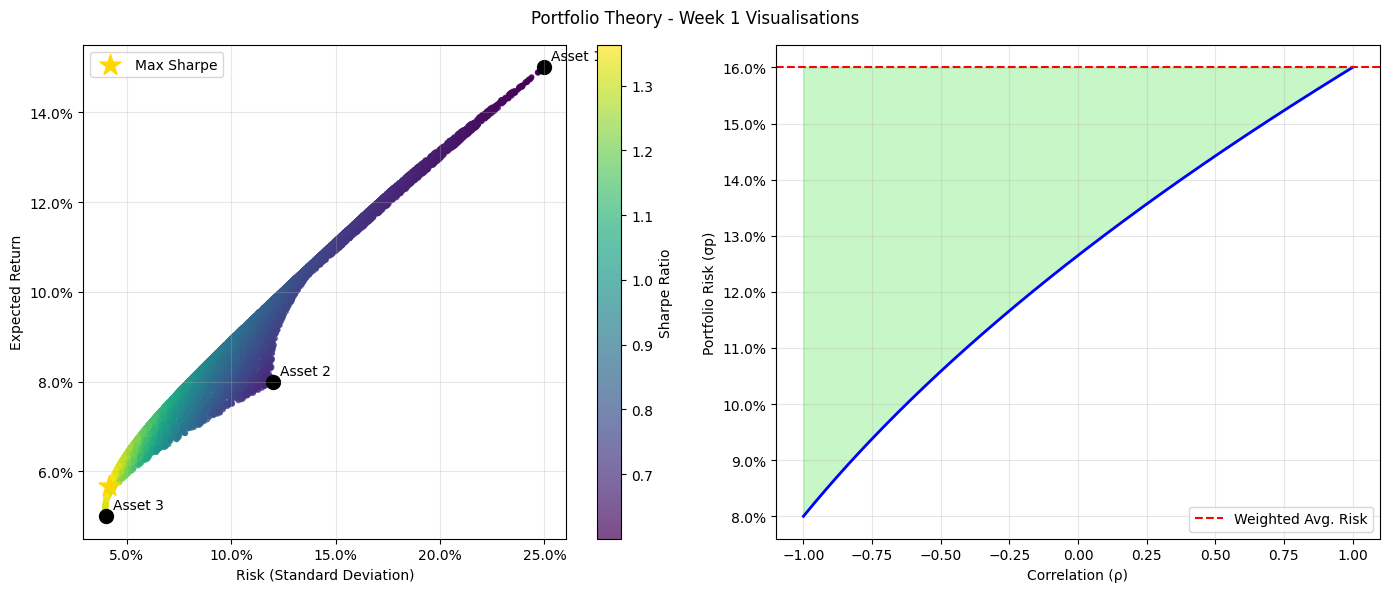

In [13]:
# Question 15
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Portfolio Theory - Week 1 Visualisations')

# Subplot 1:
sc = axes[0].scatter(port_stds, port_returns, c=sharpe_ratios, cmap='viridis', s=10, alpha=0.7)
axes[0].scatter(port_stds[max_sr_idx], port_returns[max_sr_idx], marker='*', color='gold', s=250, label='Max Sharpe')

asset_stds = np.sqrt(np.diag(Sigma_11))
axes[0].scatter(asset_stds, mu_11, marker='o', color='black', s=100)
tickers = ['Asset 1', 'Asset 2', 'Asset 3']
for i, txt in enumerate(tickers):
    axes[0].annotate(txt, (asset_stds[i], mu_11[i]), xytext=(5,5), textcoords='offset points')

cbar = plt.colorbar(sc, ax=axes[0])
cbar.set_label('Sharpe Ratio')
axes[0].set_xlabel('Risk (Standard Deviation)')
axes[0].set_ylabel('Expected Return')
axes[0].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Subplot 2
axes[1].plot(rho_array, std_p_array, color='blue', lw=2)
weighted_avg_risk = w1 * sig1 + w2 * sig2
axes[1].axhline(weighted_avg_risk, color='red', linestyle='--', label='Weighted Avg. Risk')
axes[1].fill_between(rho_array, std_p_array, weighted_avg_risk, where=(std_p_array < weighted_avg_risk), color='lightgreen', alpha=0.5)

axes[1].set_xlabel('Correlation (ρ)')
axes[1].set_ylabel('Portfolio Risk (σp)')
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('week1_plots.png', dpi=150)
print("Plot saved as 'week1_plots.png'. Displaying below:")
plt.show()